# Solar System (2D heliocentric) — minimal viewer

- 2D position in the ecliptic plane (heliocentric)
- Default date/time: now (UTC)
- Parameters: optional target date/time + visible planets (list)
- Labels: initial; if it collides, uses 2 letters (ME/MA)


In [17]:
%pip -q install numpy matplotlib skyfield pyyaml

import sys
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta, timezone

from skyfield.api import load

print("Python:", sys.version.split()[0])
print("numpy:", np.__version__)
print("matplotlib:", plt.matplotlib.__version__)


Note: you may need to restart the kernel to use updated packages.
Python: 3.13.12
numpy: 2.4.4
matplotlib: 3.10.8


In [18]:
# === Config (YAML) ===
from pathlib import Path

import yaml

CFG_PATH = Path("viewer_config.yaml")

_DEFAULTS = {
    "target_date": "",
    "target_time": "",
    "planets_to_show": ["Jupiter", "Saturn", "Uranus", "Neptune"],
    "lim_au": 50,
    "show_circular_orbits": False,
}

if not CFG_PATH.exists():
    raise FileNotFoundError(
        f"Missing {CFG_PATH.name}. Create it next to this notebook (or adjust CFG_PATH)."
    )

raw = yaml.safe_load(CFG_PATH.read_text(encoding="utf-8")) or {}
if not isinstance(raw, dict):
    raise ValueError(f"{CFG_PATH.name} must contain a YAML mapping/object at the top level")

cfg = {**_DEFAULTS, **raw}

TARGET_DATE = str(cfg.get("target_date", ""))
TARGET_TIME = str(cfg.get("target_time", ""))

PLANETS_TO_SHOW = cfg.get("planets_to_show", [])
if not isinstance(PLANETS_TO_SHOW, list) or not all(isinstance(p, str) for p in PLANETS_TO_SHOW):
    raise ValueError("planets_to_show must be a YAML list of planet name strings")

LIM_AU = float(cfg.get("lim_au", _DEFAULTS["lim_au"]))
SHOW_CIRCULAR_ORBITS = bool(cfg.get("show_circular_orbits", _DEFAULTS["show_circular_orbits"]))


In [19]:
# === Ephemeris + core functions ===

ts = load.timescale()
# DE421 spans ~1900–2050 and is enough for v1.
eph = load("de421.bsp")

sun = eph["sun"]

# Each entry is a nested object so you can extend parameters per planet.
BODIES = {
    "Mercury": {"body": eph["mercury"]},
    "Venus": {"body": eph["venus"]},
    "Earth": {"body": eph["earth"]},
    "Mars": {"body": eph["mars"]},
    "Jupiter": {"body": eph["jupiter barycenter"]},
    "Saturn": {"body": eph["saturn barycenter"]},
    "Uranus": {"body": eph["uranus barycenter"]},
    "Neptune": {"body": eph["neptune barycenter"]},
    "Pluto": {"body": eph["pluto barycenter"]},
}

ALLOWED_PLANETS = list(BODIES.keys())


def parse_target_datetime(date_str: str, time_str: str) -> datetime:
    """Return a timezone-aware datetime in UTC.

    - If TARGET_DATE or TARGET_TIME is empty, falls back to now (UTC).
    - Otherwise expects 'YYYY-MM-DD' and 'HH:MM'.
    """
    now = datetime.now(timezone.utc)
    if not date_str or not time_str:
        return now

    try:
        year, month, day = (int(x) for x in date_str.split("-"))
        hour, minute = (int(x) for x in time_str.split(":"))
        return datetime(year, month, day, hour, minute, tzinfo=timezone.utc)
    except Exception as e:
        raise ValueError(
            "Invalid format. Use TARGET_DATE='YYYY-MM-DD' and TARGET_TIME='HH:MM' (UTC), "
            "or leave them empty to use the current date/time."
        ) from e


def make_labels(names: list[str]) -> dict[str, str]:
    """Short labels: 1 letter; if it collides, 2 letters; if still collides, numeric suffix."""
    cleaned = [n.strip() for n in names]

    def base1(n: str) -> str:
        return (n[:1] or "?").upper()

    def base2(n: str) -> str:
        return (n[:2] or "??").upper()

    labels = {n: base1(n) for n in cleaned}
    inv: dict[str, list[str]] = {}
    for n, lab in labels.items():
        inv.setdefault(lab, []).append(n)

    # Resolve collisions with 2 letters
    for lab, ns in inv.items():
        if len(ns) > 1:
            for n in ns:
                labels[n] = base2(n)

    inv2: dict[str, list[str]] = {}
    for n, lab in labels.items():
        inv2.setdefault(lab, []).append(n)

    # If still collisions, add deterministic suffix 1..N
    for lab, ns in inv2.items():
        if len(ns) > 1:
            for i, n in enumerate(sorted(ns), start=1):
                labels[n] = f"{lab}{i}"

    return labels


def get_positions_au(t, planet_names: list[str]) -> dict[str, tuple[float, float]]:
    positions: dict[str, tuple[float, float]] = {}
    for name in planet_names:
        body = BODIES[name]["body"]
        x, y, _z = (body - sun).at(t).ecliptic_position().au
        positions[name] = (float(x), float(y))
    return positions


def get_dynamic_circular_orbits_au(positions: dict[str, tuple[float, float]]) -> dict[str, float]:
    """Return circle radii (AU) that pass through each planet's current position."""
    return {name: float(np.hypot(x, y)) for name, (x, y) in positions.items()}


def plot_solar(
    dt_utc: datetime,
    positions: dict[str, tuple[float, float]],
    labels: dict[str, str],
    lim_au: float,
    circular_orbits_au: dict[str, float] | None = None,
):
    fig, ax = plt.subplots(figsize=(7.6, 6.0), dpi=140)
    fig.patch.set_facecolor("black")
    ax.set_facecolor("black")

    sun_color = "#ffdd00"
    planet_color = "#ff4040"

    # Orbits (optional)
    if circular_orbits_au:
        for _name, r in circular_orbits_au.items():
            ax.add_patch(
                plt.Circle(
                    (0, 0),
                    r,
                    fill=False,
                    edgecolor="white",
                    linewidth=1,
                    alpha=0.12,
                    zorder=2,
                )
            )

    # Sun
    ax.scatter([0], [0], s=120, c=sun_color, edgecolors="none", zorder=5)

    # Planets
    for name, (x, y) in positions.items():
        ax.scatter([x], [y], s=34, c=planet_color, zorder=6)
        ax.text(
            x,
            y,
            labels.get(name, name[:1].upper()),
            color="white",
            fontsize=14,
            ha="left",
            va="bottom",
            fontweight="bold",
            zorder=7,
        )

    # Simple color legend
    from matplotlib.lines import Line2D

    handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="None",
            label="Sun",
            markerfacecolor=sun_color,
            markeredgecolor="none",
            markersize=10,
        ),
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="None",
            label="Planets",
            markerfacecolor=planet_color,
            markeredgecolor="none",
            markersize=7,
        ),
    ]
    if circular_orbits_au:
        handles.append(Line2D([0], [0], color="white", linewidth=1, alpha=0.4, label="Circular orbits"))

    leg = ax.legend(handles=handles, loc="upper right", frameon=True)
    leg.get_frame().set_facecolor("black")
    leg.get_frame().set_edgecolor("white")
    for txt in leg.get_texts():
        txt.set_color("white")

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(-lim_au, lim_au)
    ax.set_ylim(-lim_au, lim_au)

    ax.tick_params(colors="white")
    for spine in ax.spines.values():
        spine.set_color("white")

    ax.set_xlabel("AU", color="white")
    ax.set_ylabel("AU", color="white")
    ax.set_title(
        f"Solar System (heliocentric, ecliptic) — {dt_utc.isoformat(timespec='minutes')}",
        color="white",
    )

    plt.show()


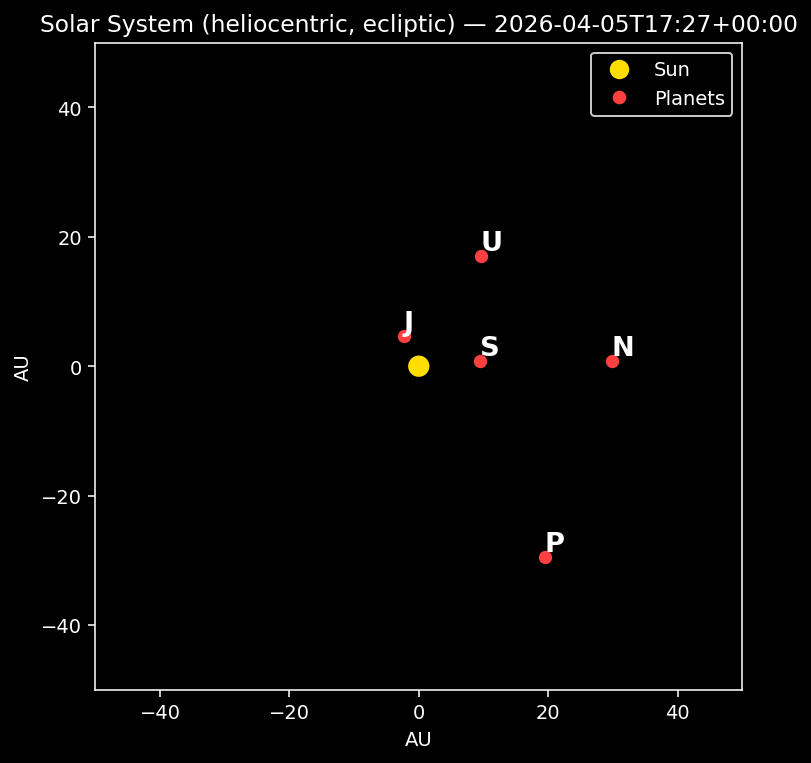

In [20]:
# === Run ===

dt_utc = parse_target_datetime(TARGET_DATE, TARGET_TIME)

invalid = [p for p in PLANETS_TO_SHOW if p not in BODIES]
if invalid:
    raise ValueError(
        "Invalid planet names in PLANETS_TO_SHOW: "
        + ", ".join(invalid)
        + "\nAllowed: "
        + ", ".join(ALLOWED_PLANETS)
    )

# Skyfield: convert UTC datetime to a Skyfield Time

t = ts.utc(
    dt_utc.year,
    dt_utc.month,
    dt_utc.day,
    dt_utc.hour,
    dt_utc.minute,
    dt_utc.second,
)

labels = make_labels(PLANETS_TO_SHOW)
positions = get_positions_au(t, PLANETS_TO_SHOW)

orbits_au = get_dynamic_circular_orbits_au(positions) if SHOW_CIRCULAR_ORBITS else None

plot_solar(dt_utc, positions, labels, LIM_AU, circular_orbits_au=orbits_au)
